# 09 — Architecture & Hopf Fibration Visualizations
Publication-quality figures for the paper.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import torch
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
from results_utils import setup_results, save_figure, save_table, save_data
from hopf_layers import ClassicalHopfLayer, RealHopfLayer, QuaternionicHopfLayer
from hopf_layers.quaternion import quaternion_normalize, quaternion_multiply

RESULTS = setup_results("09_architecture_visualization")

Results dir: C:\Users\ugure\ccode\categorical-tqft-emergence\hopf-layers\notebooks\results\09_architecture_visualization
  figures/  tables/  data/


## Figure 1: Classical Hopf Map S¹ → S³ → S²

  Saved: 09_architecture_visualization\figures\hopf_map_classical.pdf
  Saved: 09_architecture_visualization\figures\hopf_map_classical.png


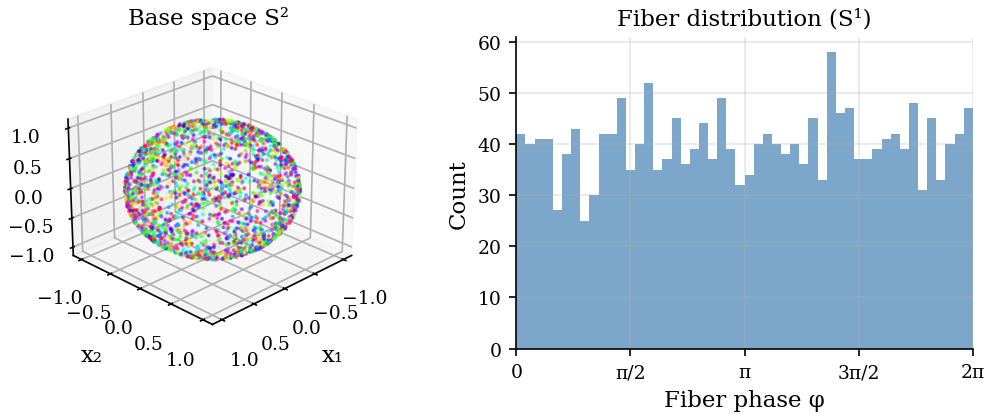

In [2]:
# Generate many points on S³ and map them to S² using ClassicalHopfLayer,
# color-coded by fiber phase.
torch.manual_seed(42)
n = 2000
q = torch.randn(n, 4)
q = q / q.norm(dim=-1, keepdim=True)

layer = ClassicalHopfLayer()
# Reshape for layer: (n, 4) -> (n, 4, 1, 1)
q_in = q.unsqueeze(-1).unsqueeze(-1)
out = layer(q_in)
base = out.base.squeeze(-1).squeeze(-1)   # (n, 3) — S² coords
fiber = out.fiber.squeeze(-1).squeeze(-1)  # (n,) — angle in [0, 2π)

# Plot: S² sphere colored by fiber phase
fig = plt.figure(figsize=(7, 3))

# Left panel: S² with fiber coloring
ax1 = fig.add_subplot(121, projection='3d')
x, y, z = base[:, 0].numpy(), base[:, 1].numpy(), base[:, 2].numpy()
colors = plt.cm.hsv((fiber.numpy() % (2 * np.pi)) / (2 * np.pi))
ax1.scatter(x, y, z, c=colors, s=1, alpha=0.5)
# Draw wireframe sphere
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 20)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))
ax1.plot_wireframe(xs, ys, zs, alpha=0.1, color='gray', linewidth=0.3)
ax1.set_title("Base space S\u00b2")
ax1.set_xlabel("x\u2081")
ax1.set_ylabel("x\u2082")
ax1.set_zlabel("x\u2083")
ax1.view_init(elev=25, azim=45)

# Right panel: Fiber distribution (histogram of angles)
ax2 = fig.add_subplot(122)
ax2.hist(fiber.numpy() % (2 * np.pi), bins=50, color='steelblue',
         edgecolor='none', alpha=0.7)
ax2.set_xlabel("Fiber phase \u03c6")
ax2.set_ylabel("Count")
ax2.set_title("Fiber distribution (S\u00b9)")
ax2.set_xlim(0, 2 * np.pi)
ax2.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax2.set_xticklabels(["0", "\u03c0/2", "\u03c0", "3\u03c0/2", "2\u03c0"])

plt.tight_layout()
save_figure(fig, "hopf_map_classical", RESULTS)
plt.show()

## Figure 2: Fiber Bundle Schematic

  Saved: 09_architecture_visualization\figures\fiber_bundle_schematic.pdf
  Saved: 09_architecture_visualization\figures\fiber_bundle_schematic.png


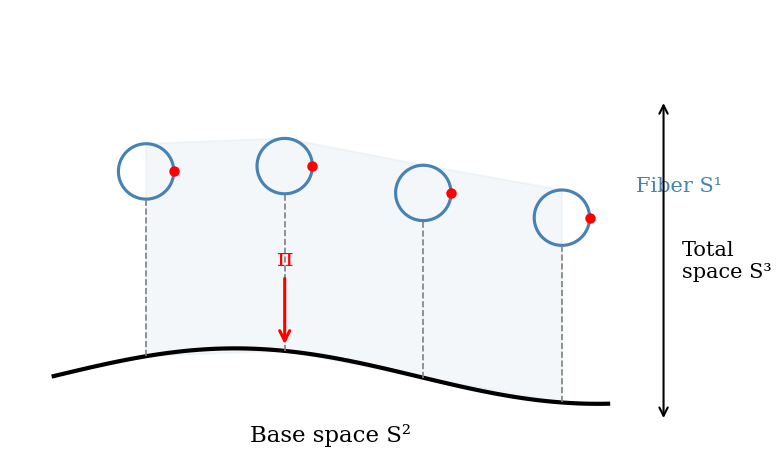

In [3]:
# Fiber bundle illustration: 2D schematic using matplotlib patches.
# Shows base space, fibers, projection arrow, and total space annotation.

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(-0.5, 7.0)
ax.set_ylim(-0.5, 4.5)
ax.set_aspect('equal')
ax.axis('off')

# Draw base space as a curved line
x_base = np.linspace(0, 6, 100)
y_base = 0.3 * np.sin(x_base * 0.8) + 0.5
ax.plot(x_base, y_base, 'k-', linewidth=2)
ax.text(3, -0.2, "Base space S\u00b2", ha='center', fontsize=11)

# Draw fibers at several points
fiber_x = [1.0, 2.5, 4.0, 5.5]
for fx in fiber_x:
    fy_base = 0.3 * np.sin(fx * 0.8) + 0.5
    # Draw a small circle (S\u00b9 fiber)
    theta = np.linspace(0, 2 * np.pi, 50)
    r = 0.3
    cx = fx + r * np.cos(theta)
    cy = fy_base + 2.0 + r * np.sin(theta)
    ax.plot(cx, cy, 'steelblue', linewidth=1.5)
    # Dashed line connecting base to fiber
    ax.plot([fx, fx], [fy_base, fy_base + 1.7], 'gray',
            linestyle='--', linewidth=0.8)
    # Red dot on fiber (section)
    ax.plot(fx + r, fy_base + 2.0, 'ro', markersize=4)

# Fiber label
ax.text(6.3, 2.5, "Fiber S\u00b9", fontsize=10, color='steelblue')

# Projection arrow
ax.annotate("\u03c0", xy=(2.5, 0.8), xytext=(2.5, 1.7),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=12, ha='center', color='red')

# Total space bracket
ax.annotate("", xy=(6.6, 0), xytext=(6.6, 3.5),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1))
ax.text(6.8, 1.75, "Total\nspace S\u00b3", fontsize=10,
        ha='left', va='center')

# Light shaded region connecting fibers to suggest total space
from matplotlib.patches import Polygon
# Create a polygon that connects the tops and bottoms of fiber regions
top_pts = []
bot_pts = []
for fx in fiber_x:
    fy_base = 0.3 * np.sin(fx * 0.8) + 0.5
    top_pts.append((fx, fy_base + 2.0 + 0.3))
    bot_pts.append((fx, fy_base))
verts = top_pts + bot_pts[::-1]
poly = Polygon(verts, alpha=0.06, color='steelblue', closed=True)
ax.add_patch(poly)

save_figure(fig, "fiber_bundle_schematic", RESULTS)
plt.show()

## Figure 3: HopfLayer Architecture

  Saved: 09_architecture_visualization\figures\hopflayer_architecture.pdf
  Saved: 09_architecture_visualization\figures\hopflayer_architecture.png


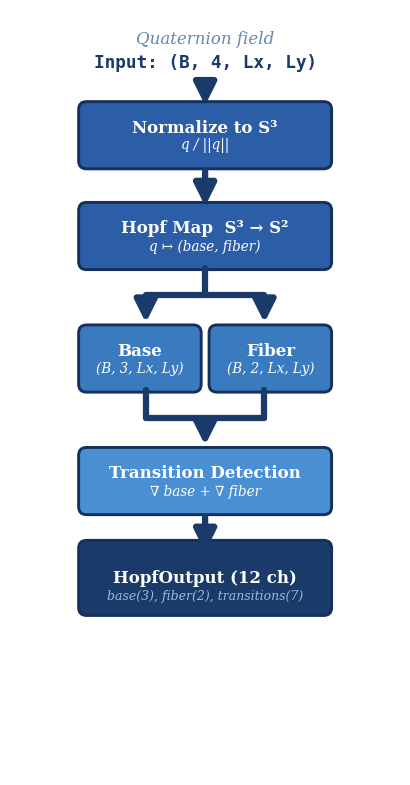

In [4]:
# Architecture block diagram: HopfLayer data flow.
# Blue color scheme for paper readability.

fig, ax = plt.subplots(figsize=(3.4, 7.0))
ax.set_xlim(0, 10)
ax.set_ylim(-1.0, 18.5)
ax.set_aspect('equal')
ax.axis('off')

# --- Color palette: blues ---
CLR_INPUT = '#2b5ea7'     # deep blue for main pipeline
CLR_SPLIT = '#3a7bbf'     # medium blue for base/fiber
CLR_TRANS = '#4a8fd4'     # lighter blue for transition
CLR_OUTPUT = '#1a3a6a'    # dark navy for output
CLR_ARROW = '#1a3a6a'     # dark navy arrows
CLR_TEXT_W = 'white'
CLR_TEXT_D = '#1a3a6a'
CLR_ANNOT = '#6688aa'     # muted blue for annotations

def draw_box(ax, xy, w, h, text, color=CLR_INPUT, text_color=CLR_TEXT_W,
             fontsize=8, subtext=None):
    """Draw a rounded box with centered text."""
    x, y = xy
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.2",
                         facecolor=color, edgecolor='#15305a',
                         linewidth=1.4)
    ax.add_patch(box)
    if subtext:
        ax.text(x + w / 2, y + h / 2 + 0.2, text,
                ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=text_color)
        ax.text(x + w / 2, y + h / 2 - 0.25, subtext,
                ha='center', va='center',
                fontsize=fontsize - 1.5, color=text_color, style='italic')
    else:
        ax.text(x + w / 2, y + h / 2, text,
                ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=text_color)

def draw_arrow(ax, start, end):
    """Draw a thick vertical arrow."""
    ax.annotate("", xy=end, xytext=start,
                arrowprops=dict(arrowstyle='-|>',
                                color=CLR_ARROW, lw=3.0,
                                mutation_scale=22))

# Layout constants
bw = 6.0   # box width
bh = 1.3   # box height
cx = 2.0   # left edge of boxes
gap = 1.4  # vertical gap between boxes (was 0.8)

# --- Input label ---
y = 17.2
ax.text(cx + bw / 2, y + 0.5, "Quaternion field",
        ha='center', va='center', fontsize=8, color=CLR_ANNOT,
        style='italic')
ax.text(cx + bw / 2, y - 0.1, "Input: (B, 4, Lx, Ly)",
        ha='center', va='center', fontsize=8.5, fontfamily='monospace',
        color=CLR_TEXT_D, fontweight='bold')

# Arrow: input -> normalize
draw_arrow(ax, (cx + bw / 2, y - 0.5), (cx + bw / 2, y - gap + 0.1))

# --- Normalize ---
y = y - gap - bh + 0.1
draw_box(ax, (cx, y), bw, bh, "Normalize to S\u00b3",
         subtext="q / ||q||", color=CLR_INPUT)

draw_arrow(ax, (cx + bw / 2, y - 0.15), (cx + bw / 2, y - gap + 0.15))

# --- Hopf Map ---
y = y - gap - bh + 0.15
draw_box(ax, (cx, y), bw, bh, "Hopf Map  S\u00b3 \u2192 S\u00b2",
         subtext="q \u21a6 (base, fiber)", color=CLR_INPUT)

# --- Split arrow: diverge into Base and Fiber ---
mid_x = cx + bw / 2
split_y = y - 0.15
left_x = cx + bw / 4
right_x = cx + 3 * bw / 4
branch_y = split_y - 0.7
next_y = y - gap - bh - 0.4

# Vertical from Hopf Map down to branch point
ax.plot([mid_x, mid_x], [split_y, branch_y], color=CLR_ARROW, lw=3.0,
        solid_capstyle='round')
# Horizontal bar
ax.plot([left_x, right_x], [branch_y, branch_y], color=CLR_ARROW, lw=3.0,
        solid_capstyle='round')
# Arrows down to Base and Fiber
draw_arrow(ax, (left_x, branch_y), (left_x, next_y + bh + 0.15))
draw_arrow(ax, (right_x, branch_y), (right_x, next_y + bh + 0.15))

# --- Base and Fiber boxes ---
y = next_y
small_w = bw / 2 - 0.3
draw_box(ax, (cx, y), small_w, bh, "Base",
         subtext="(B, 3, Lx, Ly)", color=CLR_SPLIT)
draw_box(ax, (cx + bw / 2 + 0.3, y), small_w, bh, "Fiber",
         subtext="(B, 2, Lx, Ly)", color=CLR_SPLIT)

# --- Merge arrows into Transition Detection ---
merge_y = y - 0.15
merge_branch_y = merge_y - 0.7
trans_y = y - gap - bh - 0.4

ax.plot([left_x, left_x], [merge_y, merge_branch_y], color=CLR_ARROW, lw=3.0,
        solid_capstyle='round')
ax.plot([right_x, right_x], [merge_y, merge_branch_y], color=CLR_ARROW, lw=3.0,
        solid_capstyle='round')
ax.plot([left_x, right_x], [merge_branch_y, merge_branch_y], color=CLR_ARROW,
        lw=3.0, solid_capstyle='round')
draw_arrow(ax, (mid_x, merge_branch_y), (mid_x, trans_y + bh + 0.15))

# --- Transition Detection ---
y = trans_y
draw_box(ax, (cx, y), bw, bh, "Transition Detection",
         subtext="\u2207 base + \u2207 fiber", color=CLR_TRANS)

draw_arrow(ax, (cx + bw / 2, y - 0.15), (cx + bw / 2, y - gap + 0.15))

# --- Output ---
y = y - gap - bh + 0.15
draw_box(ax, (cx, y), bw, bh + 0.2, "HopfOutput (12 ch)",
         color=CLR_OUTPUT, text_color='white')
ax.text(cx + bw / 2, y + 0.3, "base(3), fiber(2), transitions(7)",
        ha='center', va='center', fontsize=6, color='#99bbdd',
        style='italic')

save_figure(fig, "hopflayer_architecture", RESULTS)
plt.show()

## Figure 4: Three Hopf Fibrations

C:\Users\ugure\AppData\Local\Temp\ipykernel_68292\2223791893.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: 09_architecture_visualization\figures\three_hopf_fibrations.pdf
  Saved: 09_architecture_visualization\figures\three_hopf_fibrations.png


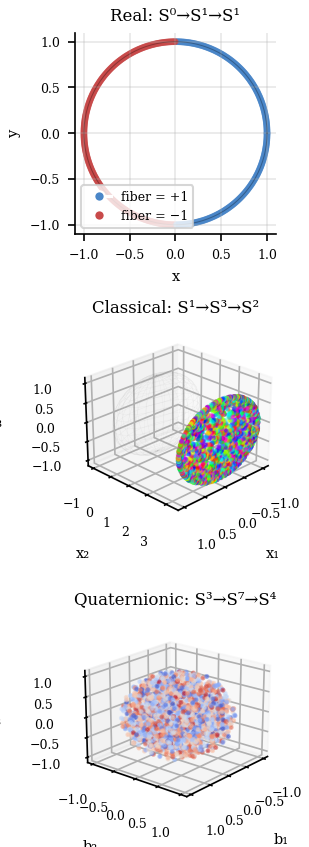

In [5]:
# Comparison of all three Hopf fibrations — VERTICAL layout for column width.

fig = plt.figure(figsize=(3.4, 6.8))
gs = gridspec.GridSpec(3, 1, hspace=0.45)

# --- Panel 1: Real Hopf  S⁰ → S¹ → S¹ ---
ax1 = fig.add_subplot(gs[0])

layer_real = RealHopfLayer()
theta_r = torch.linspace(0, 2 * np.pi, 400)
z_r = torch.stack([torch.cos(theta_r), torch.sin(theta_r)], dim=-1)
out_real = layer_real(z_r)
base_angle = out_real.base.numpy()
fiber_sign = out_real.fiber.numpy()

bx = np.cos(out_real.input_angle.numpy())
by = np.sin(out_real.input_angle.numpy())
colors_real = np.where(fiber_sign > 0, '#4a86c8', '#c84a4a')
ax1.scatter(bx, by, c=colors_real, s=5, alpha=0.8)
th_circ = np.linspace(0, 2 * np.pi, 100)
ax1.plot(np.cos(th_circ), np.sin(th_circ), 'k-', linewidth=0.5, alpha=0.3)
ax1.set_aspect('equal')
ax1.set_title("Real: S⁰→S¹→S¹", fontsize=8)
ax1.set_xlabel("x", fontsize=7)
ax1.set_ylabel("y", fontsize=7)
ax1.tick_params(labelsize=6)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4a86c8',
           markersize=5, label='fiber = +1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#c84a4a',
           markersize=5, label='fiber = −1'),
]
ax1.legend(handles=legend_elements, fontsize=6, loc='lower left')

# --- Panel 2: Classical Hopf  S¹ → S³ → S² ---
ax2 = fig.add_subplot(gs[1], projection='3d')

ax2.scatter(x, y, z, c=colors, s=2, alpha=0.5)
ax2.plot_wireframe(xs, ys, zs, alpha=0.08, color='gray', linewidth=0.2)
ax2.set_title("Classical: S¹→S³→S²", fontsize=8)
ax2.set_xlabel("x₁", fontsize=7)
ax2.set_ylabel("x₂", fontsize=7)
ax2.set_zlabel("x₃", fontsize=7)
ax2.tick_params(labelsize=6)
ax2.view_init(elev=25, azim=45)

# --- Panel 3: Quaternionic Hopf  S³ → S⁷ → S⁴ ---
ax3 = fig.add_subplot(gs[2], projection='3d')

torch.manual_seed(123)
layer_quat = QuaternionicHopfLayer()
p_q = torch.randn(2000, 4)
q_q = torch.randn(2000, 4)
out_quat = layer_quat(p_q, q_q)
base_q = out_quat.base.detach().numpy()
fiber_q = out_quat.fiber.detach().numpy()
fiber_color = fiber_q[:, 0]
fiber_color = (fiber_color - fiber_color.min()) / (fiber_color.max() - fiber_color.min() + 1e-8)

ax3.scatter(base_q[:, 0], base_q[:, 1], base_q[:, 2],
            c=plt.cm.coolwarm(fiber_color), s=2, alpha=0.5)
ax3.set_title("Quaternionic: S³→S⁷→S⁴", fontsize=8)
ax3.set_xlabel("b₁", fontsize=7)
ax3.set_ylabel("b₂", fontsize=7)
ax3.set_zlabel("b₃", fontsize=7)
ax3.tick_params(labelsize=6)
ax3.view_init(elev=20, azim=40)

plt.tight_layout()
save_figure(fig, "three_hopf_fibrations", RESULTS)
plt.show()

## Figure 5: Fiber Action Demonstration

Max base deviation under fiber rotation: 1.71e+00
  Saved: 09_architecture_visualization\figures\fiber_action_demo.pdf
  Saved: 09_architecture_visualization\figures\fiber_action_demo.png


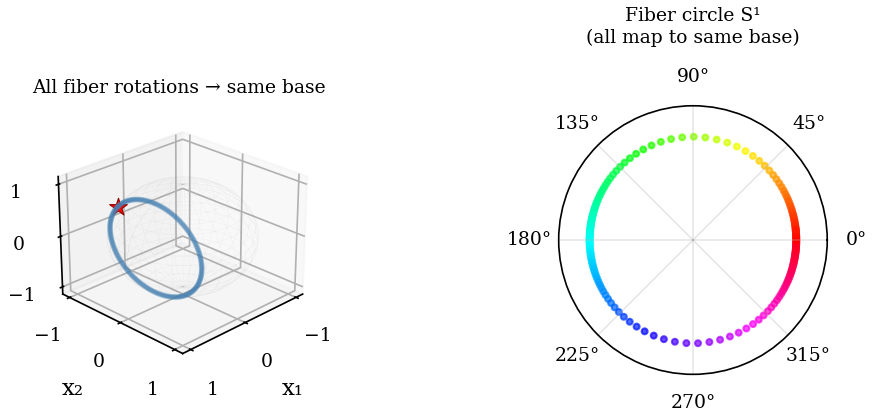

In [6]:
# Demonstrate that rotating the fiber phase leaves the base point unchanged.
# Pick a single base point on S\u00b2 and show the circle of fiber values
# that all project to the same base.

q0 = torch.tensor([[1.0, 0.5, 0.3, 0.1]])
q0 = q0 / q0.norm(dim=-1, keepdim=True)

# Generate points with same base but different fibers.
# Multiply by phase: (cos t, sin t, 0, 0) * q0
n_fib = 200
thetas = torch.linspace(0, 2 * np.pi, n_fib)
phase = torch.zeros(n_fib, 4)
phase[:, 0] = torch.cos(thetas)
phase[:, 1] = torch.sin(thetas)

q_rotated = quaternion_multiply(phase, q0.expand(n_fib, -1))

# Map through Hopf layer
q_rot_in = q_rotated.unsqueeze(-1).unsqueeze(-1)  # (n_fib, 4, 1, 1)
out_rot = layer(q_rot_in)
base_rot = out_rot.base.squeeze(-1).squeeze(-1)   # (n_fib, 3)
fiber_rot = out_rot.fiber.squeeze(-1).squeeze(-1)  # (n_fib,)

# Reference: original base point
q0_in = q0.unsqueeze(-1).unsqueeze(-1)
out0 = layer(q0_in)
base0 = out0.base.squeeze(-1).squeeze(-1)  # (1, 3)

# Check that all base points are the same
base_spread = (base_rot - base0).norm(dim=-1)
print(f"Max base deviation under fiber rotation: {base_spread.max().item():.2e}")

fig = plt.figure(figsize=(7, 3))

# Left panel: S\u00b2 showing the single base point (all rotated versions overlap)
ax1 = fig.add_subplot(121, projection='3d')
# Light wireframe sphere
ax1.plot_wireframe(xs, ys, zs, alpha=0.08, color='gray', linewidth=0.2)
# Plot rotated base points (should all be on top of each other)
bx_r = base_rot[:, 0].numpy()
by_r = base_rot[:, 1].numpy()
bz_r = base_rot[:, 2].numpy()
ax1.scatter(bx_r, by_r, bz_r, c='steelblue', s=3, alpha=0.3)
# Highlight the base point
b0 = base0[0].numpy()
ax1.scatter([b0[0]], [b0[1]], [b0[2]], c='red', s=80, marker='*',
            edgecolors='darkred', linewidths=0.5, zorder=10)
ax1.set_title("All fiber rotations \u2192 same base", fontsize=9)
ax1.set_xlabel("x\u2081")
ax1.set_ylabel("x\u2082")
ax1.set_zlabel("x\u2083")
ax1.view_init(elev=25, azim=45)

# Right panel: the fiber phases (should cover [0, 2\u03c0) uniformly)
ax2 = fig.add_subplot(122, polar=True)
fiber_vals = fiber_rot.numpy() % (2 * np.pi)
# Scatter on a circle
r_vals = np.ones_like(fiber_vals)
colors_fib = plt.cm.hsv(fiber_vals / (2 * np.pi))
ax2.scatter(fiber_vals, r_vals, c=colors_fib, s=8, alpha=0.7)
ax2.set_ylim(0, 1.3)
ax2.set_yticks([])
ax2.set_title("Fiber circle S\u00b9\n(all map to same base)", fontsize=9, pad=12)

plt.tight_layout()
save_figure(fig, "fiber_action_demo", RESULTS)
plt.show()

In [7]:
# Save summary data
save_data({
    "figures_created": ["hopf_map_classical", "fiber_bundle_schematic",
                        "hopflayer_architecture", "three_hopf_fibrations",
                        "fiber_action_demo"],
    "n_figures": [5]
}, "visualization_summary", RESULTS)

  Saved: 09_architecture_visualization\data\visualization_summary.json


{'json': WindowsPath('C:/Users/ugure/ccode/categorical-tqft-emergence/hopf-layers/notebooks/results/09_architecture_visualization/data/visualization_summary.json')}

## Summary

Figures created for the paper:

| Figure | Filename | Description |
|--------|----------|-------------|
| 1 | `hopf_map_classical` | Classical Hopf map S\u00b3 \u2192 S\u00b2 with fiber coloring and phase distribution |
| 2 | `fiber_bundle_schematic` | 2D schematic of the fiber bundle (base, fibers, projection, total space) |
| 3 | `hopflayer_architecture` | Block diagram of HopfLayer data flow (single-column width) |
| 4 | `three_hopf_fibrations` | Side-by-side comparison of Real, Classical, and Quaternionic fibrations |
| 5 | `fiber_action_demo` | Fiber action preserves base point (invariance demonstration) |

All figures saved as PDF (arxiv primary) and PNG (notebook preview) in `results/09_architecture_visualization/figures/`.